# v5 Final Review — Pre-Modelling Audit

Comprehensive review of `within_league_transfers_v5.parquet` before modelling.

**No decisions are made here** — only analysis and suggestions. Every section ends with a tagged `DECISION NEEDED` block.

**v5 composition (120 columns):**

| Group | Cols | Description |
|-------|------|-------------|
| Structural/ID | 22 | player_id, age, height, weight, financials, minutes, position, season, team, comp |
| Twelve Player QS | 40 | 20 from + 20 to (composite player qualities by Twelve Football) |
| Team qualities | 14 | 7 from projected + 7 to current |
| Team z-scores | 42 | 21 from projected + 21 to current |

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=0.85)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 130)
pd.set_option("display.float_format", "{:.3f}".format)

DATA_PATH = "../../../thesis_data/processed_data/thesis_model_dataset/within_league_transfers_v5.parquet"
df = pd.read_parquet(DATA_PATH)
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

Shape: 18,065 rows x 120 columns


---
## 1. Column classification

In [2]:
TWELVE_QS_NAMES = [
    "Active defence", "Aerial threat", "Box threat", "Chance prevention",
    "Composure", "Defensive heading", "Dribbling", "Effectiveness",
    "Finishing", "Hold-up play", "Intelligent defence", "Involvement",
    "Passing quality", "Poaching", "Pressing", "Progression",
    "Providing teammates", "Run quality", "Territorial dominance", "Winning duels",
]

from_pqs = [f"from_{n}" for n in TWELVE_QS_NAMES]
to_pqs   = [f"to_{n}" for n in TWELVE_QS_NAMES]

from_tq  = [c for c in df.columns if c.startswith("from_q_proj_")]
to_tq    = [c for c in df.columns if c.startswith("to_q_") and "z_" not in c]

from_tz  = [c for c in df.columns if c.startswith("from_z_proj_")]
to_tz    = [c for c in df.columns if c.startswith("to_z_") and not c.startswith("to_z_proj")]

structural = [c for c in df.columns if c not in set(from_pqs + to_pqs + from_tq + to_tq + from_tz + to_tz)]

groups = {
    "Structural/ID": structural,
    "Player QS (from)": from_pqs,
    "Player QS (to)": to_pqs,
    "Team qualities (from proj)": from_tq,
    "Team qualities (to curr)": to_tq,
    "Team z-scores (from proj)": from_tz,
    "Team z-scores (to curr)": to_tz,
}

print(f"{'Group':<30s} {'Cols':>5s}  {'Total nulls':>12s}  {'Max null %':>10s}")
print("-" * 65)
for name, cols in groups.items():
    total_nulls = df[cols].isnull().sum().sum()
    max_null_pct = (100 * df[cols].isnull().sum() / len(df)).max()
    print(f"{name:<30s} {len(cols):>5d}  {total_nulls:>12,}  {max_null_pct:>9.1f}%")
print(f"{'TOTAL':<30s} {sum(len(c) for c in groups.values()):>5d}")

Group                           Cols   Total nulls  Max null %
-----------------------------------------------------------------
Structural/ID                     22        68,421       77.0%
Player QS (from)                  20        29,404       52.5%
Player QS (to)                    20        29,506       52.5%
Team qualities (from proj)         7         6,167        4.9%
Team qualities (to curr)           7         4,270        3.4%
Team z-scores (from proj)         22        19,386        4.9%
Team z-scores (to curr)           22        13,427        3.4%
TOTAL                            120


---
## 2. Full null map — every column

In [3]:
null_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.values,
    "nulls": df.isnull().sum().values,
    "null_pct": (100 * df.isnull().sum() / len(df)).round(1).values,
    "nunique": df.nunique().values,
})

# Tag group
def tag_group(col):
    if col in set(from_pqs): return "Player QS (from)"
    if col in set(to_pqs): return "Player QS (to)"
    if col in set(from_tq): return "Team Q (from proj)"
    if col in set(to_tq): return "Team Q (to curr)"
    if col in set(from_tz): return "Team Z (from proj)"
    if col in set(to_tz): return "Team Z (to curr)"
    return "Structural"

null_summary["group"] = null_summary["column"].apply(tag_group)

print("All columns with nulls > 0:")
with_nulls = null_summary[null_summary["nulls"] > 0].sort_values("null_pct", ascending=False)
print(with_nulls[["column", "group", "nulls", "null_pct"]].to_string(index=False))
print(f"\nColumns with zero nulls: {(null_summary['nulls'] == 0).sum()} / {len(null_summary)}")

All columns with nulls > 0:
                                                              column              group  nulls  null_pct
                                                      wyscout_height         Structural  13911    77.000
                                                      wyscout_weight         Structural  13911    77.000
                                            to_Territorial dominance     Player QS (to)   9487    52.500
                                                to_Chance prevention     Player QS (to)   9487    52.500
                                          from_Territorial dominance   Player QS (from)   9487    52.500
                                              from_Chance prevention   Player QS (from)   9487    52.500
                                                       from_Poaching   Player QS (from)   8675    48.000
                                                         to_Poaching     Player QS (to)   8362    46.300
                           

---
## 3. Structural columns deep dive

In [4]:
# 3a. Player demographics
print("=== Player demographics ===")
print(f"\nwyscout_height: {df['wyscout_height'].describe().to_string()}")
print(f"  nulls: {df['wyscout_height'].isnull().sum():,} ({100*df['wyscout_height'].isnull().sum()/len(df):.1f}%)")

print(f"\nwyscout_weight: {df['wyscout_weight'].describe().to_string()}")
print(f"  nulls: {df['wyscout_weight'].isnull().sum():,} ({100*df['wyscout_weight'].isnull().sum()/len(df):.1f}%)")

# Are height/weight null for the same rows?
both_null = (df["wyscout_height"].isnull() & df["wyscout_weight"].isnull()).sum()
either_null = (df["wyscout_height"].isnull() | df["wyscout_weight"].isnull()).sum()
print(f"\nBoth null: {both_null:,}  Either null: {either_null:,}  → {'Same rows' if both_null == either_null else 'Different rows'}")

print(f"\nplayer_season_age:")
print(df["player_season_age"].describe().to_string())

=== Player demographics ===

wyscout_height: count   4154.000
mean     178.321
std       23.162
min        0.000
25%      176.000
50%      181.000
75%      185.000
max      200.000
  nulls: 13,911 (77.0%)

wyscout_weight: count   4154.000
mean      73.134
std       15.768
min        0.000
25%       71.000
50%       75.000
75%       80.000
max      101.000
  nulls: 13,911 (77.0%)

Both null: 13,911  Either null: 13,911  → Same rows

player_season_age:
count   18065.000
mean       26.279
std         4.178
min        12.983
25%        23.220
50%        25.982
75%        29.128
max        54.127


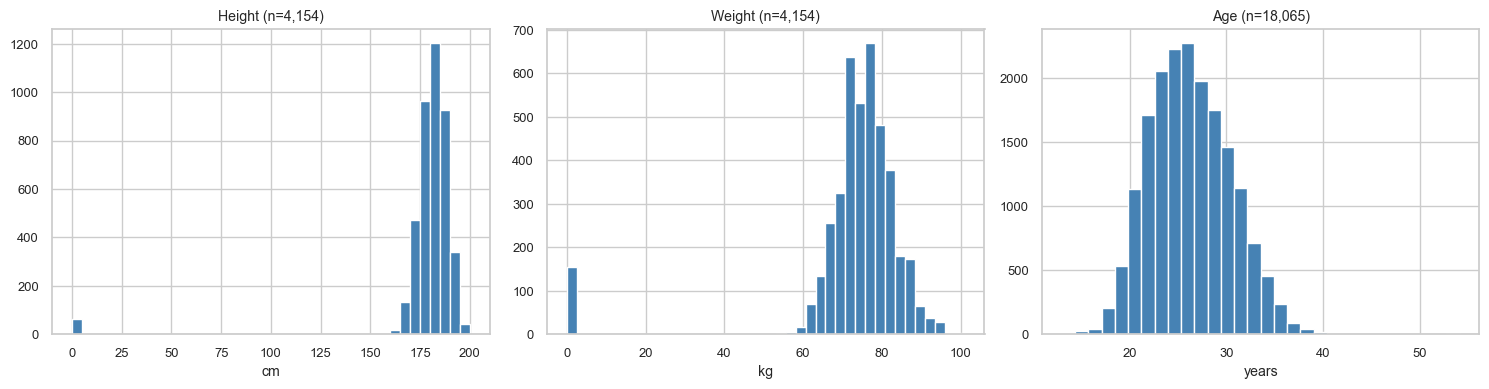

In [5]:
# 3b. Height/weight distributions (non-null)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df["wyscout_height"].dropna(), bins=40, color="steelblue", edgecolor="white")
axes[0].set_title(f"Height (n={df['wyscout_height'].notna().sum():,})")
axes[0].set_xlabel("cm")

axes[1].hist(df["wyscout_weight"].dropna(), bins=40, color="steelblue", edgecolor="white")
axes[1].set_title(f"Weight (n={df['wyscout_weight'].notna().sum():,})")
axes[1].set_xlabel("kg")

axes[2].hist(df["player_season_age"], bins=30, color="steelblue", edgecolor="white")
axes[2].set_title(f"Age (n={len(df):,})")
axes[2].set_xlabel("years")

plt.tight_layout()
plt.show()

In [6]:
# 3c. Transfer financials
print("=== Transfer financials ===")
print(f"\ntm_transfer_value:")
print(df["tm_transfer_value"].describe().to_string())
print(f"  nulls: {df['tm_transfer_value'].isnull().sum():,} ({100*df['tm_transfer_value'].isnull().sum()/len(df):.1f}%)")

print(f"\ntm_transfer_fee:")
print(df["tm_transfer_fee"].describe().to_string())
print(f"  nulls: {df['tm_transfer_fee'].isnull().sum():,} ({100*df['tm_transfer_fee'].isnull().sum()/len(df):.1f}%)")

# Fee = 0 likely means free transfer
fee_zero = (df["tm_transfer_fee"] == 0).sum()
print(f"\ntm_transfer_fee == 0 (free transfers): {fee_zero:,} ({100*fee_zero/len(df):.1f}%)")

=== Transfer financials ===

tm_transfer_value:
count       16078.000
mean       729772.049
std       3153166.317
min             0.000
25%        100000.000
50%        225000.000
75%        400000.000
max     130000000.000
  nulls: 1,987 (11.0%)

tm_transfer_fee:
count       11631.000
mean       415728.057
std       3688849.024
min             0.000
25%             0.000
50%             0.000
75%             0.000
max     120000000.000
  nulls: 6,434 (35.6%)

tm_transfer_fee == 0 (free transfers): 10,323 (57.1%)


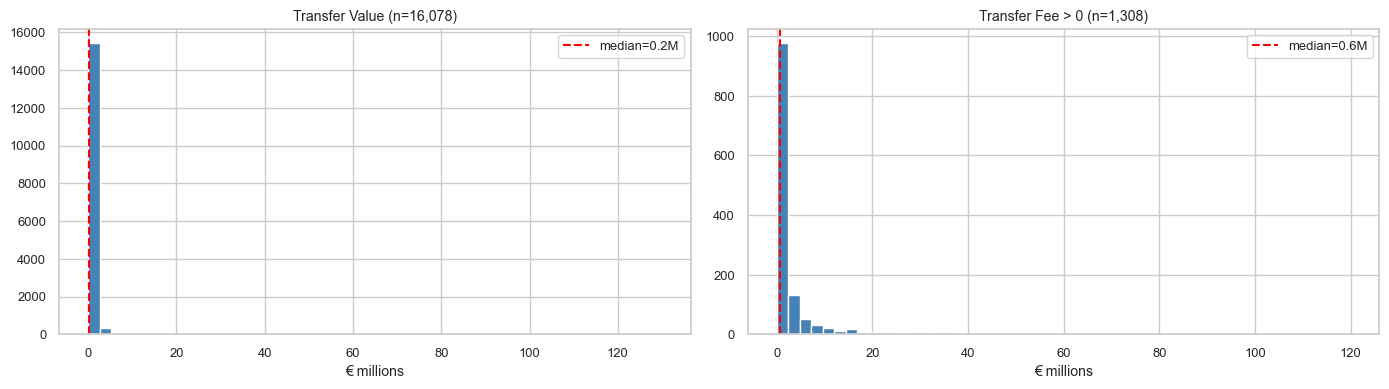

In [7]:
# 3d. Financial distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

val = df["tm_transfer_value"].dropna()
axes[0].hist(val / 1e6, bins=50, color="steelblue", edgecolor="white")
axes[0].set_title(f"Transfer Value (n={len(val):,})")
axes[0].set_xlabel("€ millions")
axes[0].axvline(val.median()/1e6, color="red", ls="--", label=f"median={val.median()/1e6:.1f}M")
axes[0].legend()

fee = df["tm_transfer_fee"].dropna()
fee_pos = fee[fee > 0]
axes[1].hist(fee_pos / 1e6, bins=50, color="steelblue", edgecolor="white")
axes[1].set_title(f"Transfer Fee > 0 (n={len(fee_pos):,})")
axes[1].set_xlabel("€ millions")
axes[1].axvline(fee_pos.median()/1e6, color="red", ls="--", label=f"median={fee_pos.median()/1e6:.1f}M")
axes[1].legend()

plt.tight_layout()
plt.show()

=== Playing time ===

from_Minutes: min=900, max=6850, median=1646
to_Minutes:   min=900, max=7370, median=1621


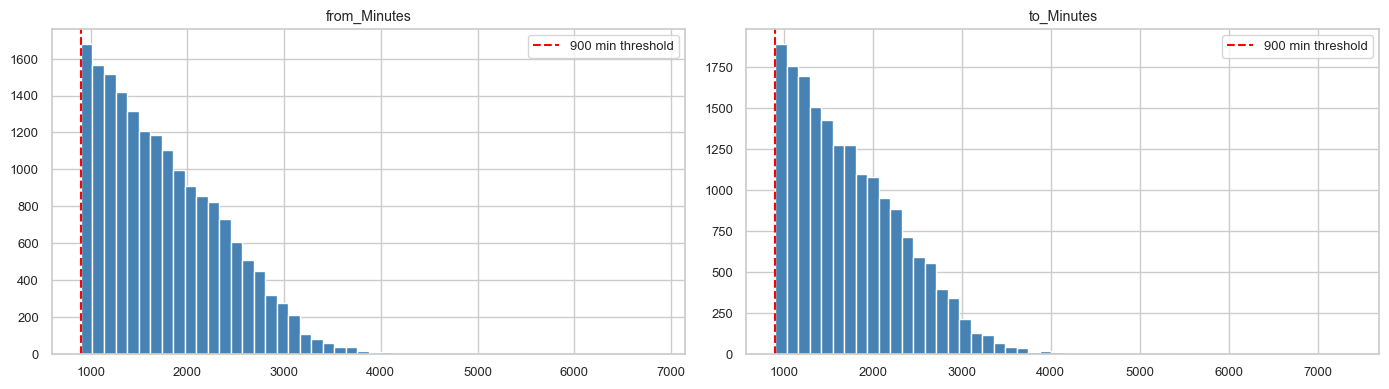

In [8]:
# 3e. Playing time
print("=== Playing time ===")
print(f"\nfrom_Minutes: min={df['from_Minutes'].min()}, max={df['from_Minutes'].max()}, median={df['from_Minutes'].median():.0f}")
print(f"to_Minutes:   min={df['to_Minutes'].min()}, max={df['to_Minutes'].max()}, median={df['to_Minutes'].median():.0f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df["from_Minutes"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("from_Minutes")
axes[0].axvline(900, color="red", ls="--", label="900 min threshold")
axes[0].legend()

axes[1].hist(df["to_Minutes"], bins=50, color="steelblue", edgecolor="white")
axes[1].set_title("to_Minutes")
axes[1].axvline(900, color="red", ls="--", label="900 min threshold")
axes[1].legend()

plt.tight_layout()
plt.show()

In [9]:
# 3f. Position distribution
positions = df["from_position"].value_counts()
print("Position distribution:")
print(positions.to_string())
print(f"\nfrom_position == to_position for all rows: {(df['from_position'] == df['to_position']).all()}")

Position distribution:
from_position
Midfielder          5230
Central Defender    4766
Full Back           3812
Striker             2422
Winger              1835

from_position == to_position for all rows: True


In [10]:
# 3g. Season and competition coverage
print("=== Season coverage ===")
print(df["from_season"].value_counts().sort_index().to_string())

print(f"\n=== Competition coverage ===")
print(f"Unique competitions: {df['from_competition'].nunique()}")
comp_counts = df["from_competition"].value_counts()
print(f"\nTop 20:")
print(comp_counts.head(20).to_string())
print(f"\nCompetitions with < 20 transfers: {(comp_counts < 20).sum()}")
print(f"Competitions with < 10 transfers: {(comp_counts < 10).sum()}")

=== Season coverage ===
from_season
2018    2236
2019    2126
2020    2280
2021    3048
2022    3051
2023    3618
2024    1706

=== Competition coverage ===
Unique competitions: 240

Top 20:
from_competition
520      1154
796       382
143       368
43327     355
797       293
688       281
295       275
350       261
527       257
1414      252
359       248
725       241
43338     228
358       225
506       220
351       217
810       203
535       203
843       202
346       188

Competitions with < 20 transfers: 64
Competitions with < 10 transfers: 47


In [11]:
# 3h. comp_division and comp_season nulls
print("=== Comp metadata nulls ===")
for c in ["from_comp_division", "from_comp_season_id", "from_comp_season_name"]:
    n = df[c].isnull().sum()
    print(f"  {c:30s} nulls={n:,} ({100*n/len(df):.1f}%)")

# Are these the same rows?
div_null = df["from_comp_division"].isnull()
sid_null = df["from_comp_season_id"].isnull()
print(f"\nSame null rows for all 3: {(div_null == sid_null).all()}")
print(f"Null rows: {div_null.sum():,} ({100*div_null.sum()/len(df):.1f}%)")

# Which competitions have null division?
null_div_comps = df.loc[div_null, "from_competition"].nunique()
print(f"Competitions with null division: {null_div_comps}")
print(f"\nSample:")
print(df.loc[div_null, ["from_competition", "from_season"]].drop_duplicates().head(10).to_string(index=False))

=== Comp metadata nulls ===
  from_comp_division             nulls=5,363 (29.7%)
  from_comp_season_id            nulls=5,363 (29.7%)
  from_comp_season_name          nulls=5,363 (29.7%)

Same null rows for all 3: True
Null rows: 5,363 (29.7%)
Competitions with null division: 74

Sample:
 from_competition  from_season
              139         2023
              139         2024
              142         2018
              142         2021
              142         2022
              142         2023
              142         2024
              246         2020
              246         2021
              246         2022


In [12]:
# 3i. wy_player_id — unique players
n_players = df["wy_player_id"].nunique()
transfers_per_player = df.groupby("wy_player_id").size()
print(f"Unique players: {n_players:,}")
print(f"Transfers per player:")
print(transfers_per_player.describe().to_string())
print(f"\nPlayers with 5+ transfers: {(transfers_per_player >= 5).sum()}")
print(f"Players with 1 transfer:  {(transfers_per_player == 1).sum()} ({100*(transfers_per_player == 1).sum()/n_players:.1f}%)")

Unique players: 14,487
Transfers per player:
count   14487.000
mean        1.247
std         0.557
min         1.000
25%         1.000
50%         1.000
75%         1.000
max         6.000

Players with 5+ transfers: 19
Players with 1 transfer:  11638 (80.3%)


### DECISION NEEDED — Structural columns

- `wyscout_height` & `wyscout_weight`: **~77% null**. Drop, impute, or ignore?
- `tm_transfer_value`: **11% null**. Keep as feature? Impute?
- `tm_transfer_fee`: **35.6% null**. Keep, drop, or derive from value?
- `from_comp_division`, `from_comp_season_id/name` (+ to mirrors): **29.7% null**. Drop these metadata cols or keep?
- `wy_player_id`: needed for interpretation — drop before modelling?
- Competitions with very few transfers — any minimum threshold?

---
## 4. Twelve Player Quality Scores — null analysis by position

In [13]:
# 4a. Null counts by position (from side)
pos_list = sorted(df["from_position"].unique())

null_pqs = pd.DataFrame(index=[n for n in TWELVE_QS_NAMES])
for pos in pos_list:
    mask = df["from_position"] == pos
    n = mask.sum()
    for qname in TWELVE_QS_NAMES:
        col = f"from_{qname}"
        null_pqs.loc[qname, pos] = f"{df.loc[mask, col].isnull().sum()} ({100*df.loc[mask, col].isnull().sum()/n:.1f}%)"

null_pqs["TOTAL"] = [f"{df[f'from_{q}'].isnull().sum()} ({100*df[f'from_{q}'].isnull().sum()/len(df):.1f}%)" for q in TWELVE_QS_NAMES]

print("Twelve Player QS — null counts by position (FROM side)")
null_pqs

Twelve Player QS — null counts by position (FROM side)


,Central Defender,Full Back,Midfielder,Striker,Winger,TOTAL
Active defence,1 (0.0%),0 (0.0%),0 (0.0%),77 (3.2%),2 (0.1%),80 (0.4%)
Aerial threat,3 (0.1%),33 (0.9%),8 (0.2%),1 (0.0%),1 (0.1%),46 (0.3%)
Box threat,0 (0.0%),0 (0.0%),0 (0.0%),1 (0.0%),0 (0.0%),1 (0.0%)
Chance prevention,0 (0.0%),0 (0.0%),5230 (100.0%),2422 (100.0%),1835 (100.0%),9487 (52.5%)
Composure,0 (0.0%),0 (0.0%),0 (0.0%),1 (0.0%),0 (0.0%),1 (0.0%)
Defensive heading,0 (0.0%),0 (0.0%),2 (0.0%),5 (0.2%),7 (0.4%),14 (0.1%)
Dribbling,119 (2.5%),0 (0.0%),1 (0.0%),1 (0.0%),0 (0.0%),121 (0.7%)
Effectiveness,71 (1.5%),37 (1.0%),15 (0.3%),38 (1.6%),0 (0.0%),161 (0.9%)
Finishing,71 (1.5%),37 (1.0%),15 (0.3%),1 (0.0%),0 (0.0%),124 (0.7%)
Hold-up play,1104 (23.2%),32 (0.8%),0 (0.0%),1 (0.0%),0 (0.0%),1137 (6.3%)


In [14]:
# 4b. Same for TO side
null_pqs_to = pd.DataFrame(index=[n for n in TWELVE_QS_NAMES])
for pos in pos_list:
    mask = df["to_position"] == pos
    n = mask.sum()
    for qname in TWELVE_QS_NAMES:
        col = f"to_{qname}"
        null_pqs_to.loc[qname, pos] = f"{df.loc[mask, col].isnull().sum()} ({100*df.loc[mask, col].isnull().sum()/n:.1f}%)"

null_pqs_to["TOTAL"] = [f"{df[f'to_{q}'].isnull().sum()} ({100*df[f'to_{q}'].isnull().sum()/len(df):.1f}%)" for q in TWELVE_QS_NAMES]

print("Twelve Player QS — null counts by position (TO side)")
null_pqs_to

Twelve Player QS — null counts by position (TO side)


,Central Defender,Full Back,Midfielder,Striker,Winger,TOTAL
Active defence,3 (0.1%),0 (0.0%),4 (0.1%),133 (5.5%),2 (0.1%),142 (0.8%)
Aerial threat,9 (0.2%),30 (0.8%),18 (0.3%),0 (0.0%),2 (0.1%),59 (0.3%)
Box threat,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
Chance prevention,0 (0.0%),0 (0.0%),5230 (100.0%),2422 (100.0%),1835 (100.0%),9487 (52.5%)
Composure,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
Defensive heading,0 (0.0%),0 (0.0%),4 (0.1%),4 (0.2%),10 (0.5%),18 (0.1%)
Dribbling,215 (4.5%),1 (0.0%),6 (0.1%),1 (0.0%),0 (0.0%),223 (1.2%)
Effectiveness,78 (1.6%),39 (1.0%),10 (0.2%),46 (1.9%),0 (0.0%),173 (1.0%)
Finishing,78 (1.6%),39 (1.0%),10 (0.2%),0 (0.0%),0 (0.0%),127 (0.7%)
Hold-up play,1260 (26.4%),60 (1.6%),5 (0.1%),0 (0.0%),0 (0.0%),1325 (7.3%)


In [15]:
# 4c. Identify the problematic qualities
print("Player QS null severity (from side):")
print(f"{'Quality':<25s} {'Total nulls':>12s} {'Null %':>8s}  Position pattern")
print("-" * 80)

for qname in TWELVE_QS_NAMES:
    col = f"from_{qname}"
    total = df[col].isnull().sum()
    pct = 100 * total / len(df)
    # Which positions are affected?
    pos_pcts = []
    for pos in pos_list:
        mask = df["from_position"] == pos
        n = mask.sum()
        pn = 100 * df.loc[mask, col].isnull().sum() / n
        if pn > 1:
            pos_pcts.append(f"{pos[:6]}={pn:.0f}%")
    pattern = ", ".join(pos_pcts) if pos_pcts else "< 1% all positions"
    flag = " *** " if pct > 5 else ""
    print(f"{qname:<25s} {total:>12,} {pct:>7.1f}%  {pattern}{flag}")

Player QS null severity (from side):
Quality                    Total nulls   Null %  Position pattern
--------------------------------------------------------------------------------
Active defence                      80     0.4%  Strike=3%
Aerial threat                       46     0.3%  < 1% all positions
Box threat                           1     0.0%  < 1% all positions
Chance prevention                9,487    52.5%  Midfie=100%, Strike=100%, Winger=100% *** 
Composure                            1     0.0%  < 1% all positions
Defensive heading                   14     0.1%  < 1% all positions
Dribbling                          121     0.7%  Centra=2%
Effectiveness                      161     0.9%  Centra=1%, Strike=2%
Finishing                          124     0.7%  Centra=1%
Hold-up play                     1,137     6.3%  Centra=23% *** 
Intelligent defence                  1     0.0%  < 1% all positions
Involvement                          1     0.0%  < 1% all positions
Pass

In [16]:
# 4d. Are the high-null qualities (Chance prevention, Poaching, Territorial dominance)
# null for specific positions only?
problem_qs = ["Chance prevention", "Poaching", "Territorial dominance", "Hold-up play"]

for qname in problem_qs:
    print(f"\n{'='*60}")
    print(f"{qname}:")
    for side in ["from", "to"]:
        col = f"{side}_{qname}"
        print(f"  {side} side:")
        for pos in pos_list:
            mask = df["from_position"] == pos
            n = mask.sum()
            n_null = df.loc[mask, col].isnull().sum()
            n_valid = n - n_null
            print(f"    {pos:20s}  valid={n_valid:,}  null={n_null:,} ({100*n_null/n:.1f}%)")


Chance prevention:
  from side:
    Central Defender      valid=4,766  null=0 (0.0%)
    Full Back             valid=3,812  null=0 (0.0%)
    Midfielder            valid=0  null=5,230 (100.0%)
    Striker               valid=0  null=2,422 (100.0%)
    Winger                valid=0  null=1,835 (100.0%)
  to side:
    Central Defender      valid=4,766  null=0 (0.0%)
    Full Back             valid=3,812  null=0 (0.0%)
    Midfielder            valid=0  null=5,230 (100.0%)
    Striker               valid=0  null=2,422 (100.0%)
    Winger                valid=0  null=1,835 (100.0%)

Poaching:
  from side:
    Central Defender      valid=1,863  null=2,903 (60.9%)
    Full Back             valid=1,988  null=1,824 (47.8%)
    Midfielder            valid=1,287  null=3,943 (75.4%)
    Striker               valid=2,421  null=1 (0.0%)
    Winger                valid=1,831  null=4 (0.2%)
  to side:
    Central Defender      valid=1,903  null=2,863 (60.1%)
    Full Back             valid=2,160  nu

### DECISION NEEDED — Player Quality Scores

Three qualities have **massive** position-specific nulls:
- **Chance prevention** (~52.5% null): likely null for attackers (Strikers, Wingers)
- **Territorial dominance** (~52.5% null): same pattern
- **Poaching** (~48% null): likely null for defenders
- **Hold-up play** (~6-7% null): partially missing

Options:
1. **Drop** these qualities entirely (lose signal but clean data)
2. **Keep per-position** — only use them for positions where they're populated
3. **Impute** with 0 or position mean (risky — they're null by design, not by accident)
4. **Build position-specific models** that include/exclude qualities based on availability

---
## 5. Twelve Player QS — distributions by position

In [17]:
# 5a. Descriptive stats per position (from side)
for pos in pos_list:
    sub = df.loc[df["from_position"] == pos, from_pqs]
    print(f"\n{'='*100}")
    print(f"{pos} (n={len(sub):,})")
    print(sub.describe().T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]].round(3).to_string())


Central Defender (n=4,766)
                              count   mean   std    min    25%    50%   75%   max
from_Active defence        4765.000  0.058 0.675 -2.261 -0.410  0.035 0.499 3.532
from_Aerial threat         4763.000  0.077 0.617 -2.333 -0.330  0.076 0.479 2.772
from_Box threat            4766.000  0.082 0.663 -1.307 -0.400 -0.017 0.486 3.588
from_Chance prevention     4766.000 -0.148 0.581 -2.914 -0.524 -0.115 0.257 1.933
from_Composure             4766.000 -0.030 0.584 -2.008 -0.416 -0.049 0.345 3.058
from_Defensive heading     4766.000  0.149 0.800 -2.838 -0.391  0.160 0.702 3.181
from_Dribbling             4647.000 -0.011 0.578 -1.722 -0.337 -0.083 0.221 3.638
from_Effectiveness         4695.000  0.010 0.364 -1.219 -0.240 -0.018 0.233 1.844
from_Finishing             4695.000  0.035 0.802 -1.997 -0.564 -0.205 0.515 4.244
from_Hold-up play          3662.000  0.015 0.460 -1.505 -0.299 -0.002 0.304 2.415
from_Intelligent defence   4766.000  0.059 0.604 -1.894 -0.357  0.034 

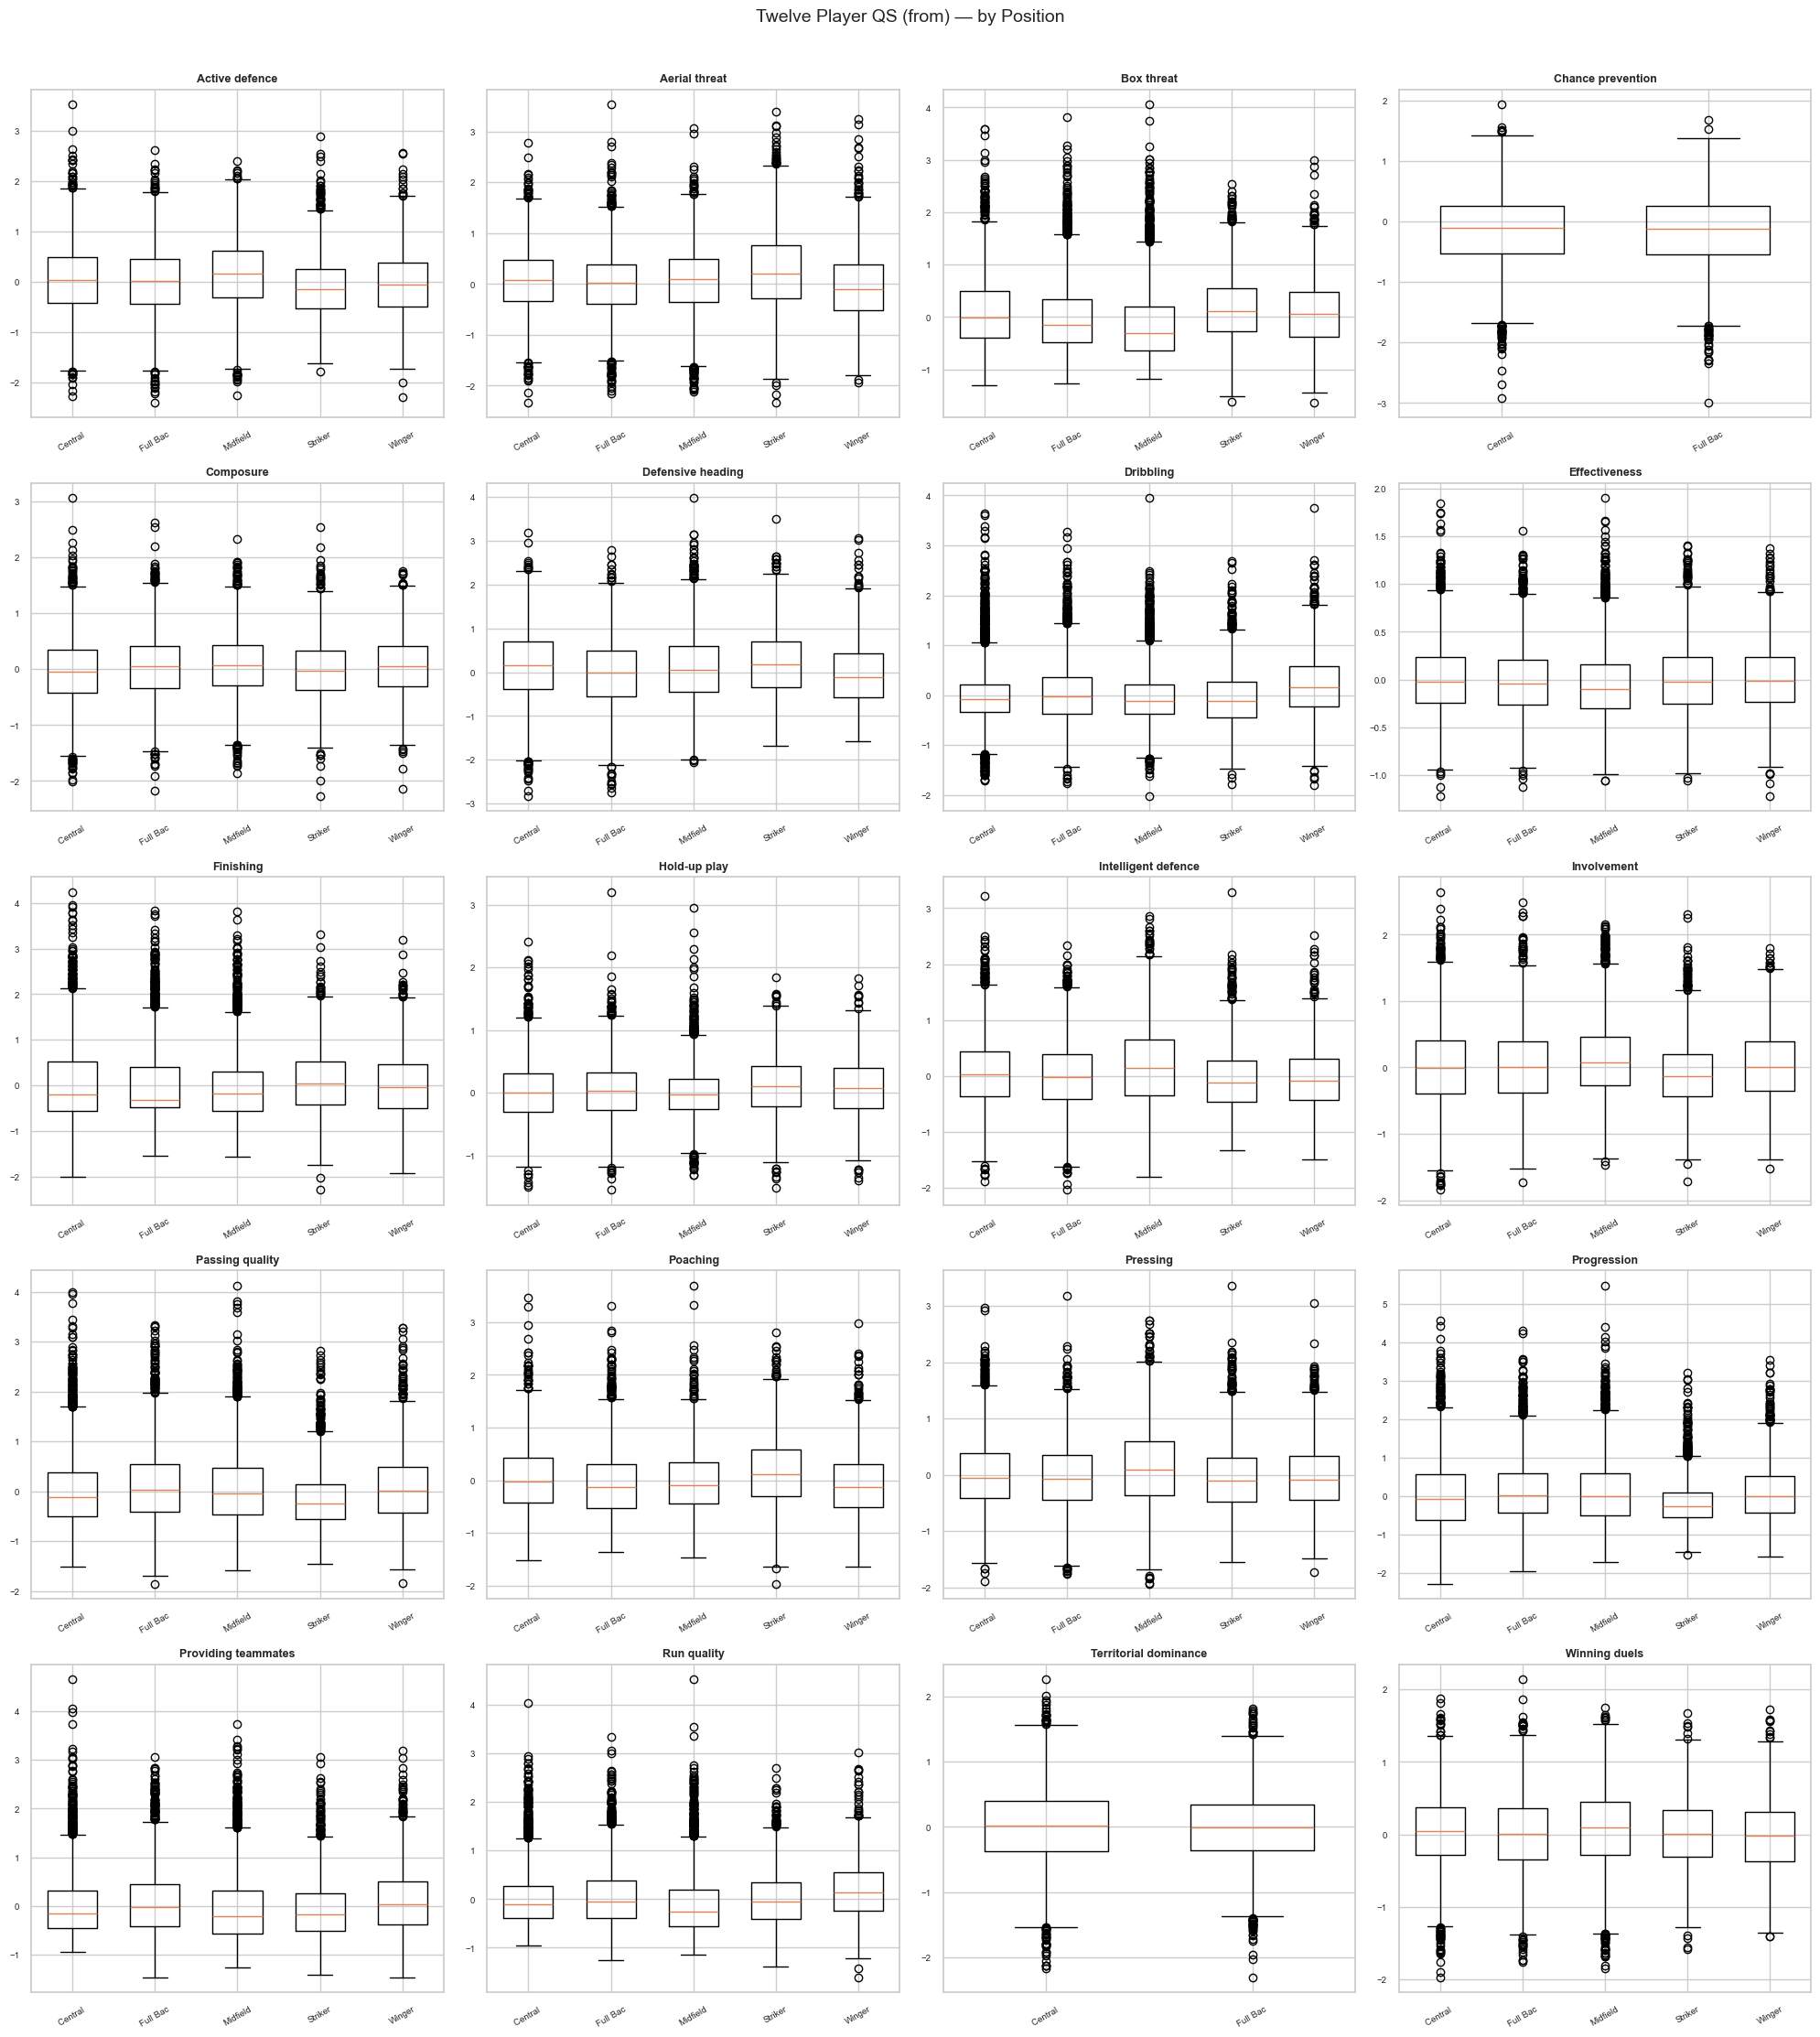

In [18]:
# 5b. Boxplots — from Player QS by position
fig, axes = plt.subplots(5, 4, figsize=(20, 22))
axes = axes.flatten()

for i, qname in enumerate(TWELVE_QS_NAMES):
    ax = axes[i]
    col = f"from_{qname}"
    data = [df.loc[df["from_position"] == p, col].dropna() for p in pos_list]
    # Filter out empty series
    labels = [p[:8] for p, d in zip(pos_list, data)]
    data_filt = [d.values for d in data if len(d) > 0]
    labels_filt = [l for l, d in zip(labels, data) if len(d) > 0]
    if data_filt:
        ax.boxplot(data_filt, labels=labels_filt, widths=0.6)
    ax.set_title(qname, fontsize=9, fontweight="bold")
    ax.tick_params(axis="x", labelsize=7, rotation=30)
    ax.tick_params(axis="y", labelsize=7)

fig.suptitle("Twelve Player QS (from) — by Position", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [19]:
# 5c. from vs to correlation per quality
print("Player QS: from ↔ to correlation (same quality, same player)")
print(f"{'Quality':<25s} {'r':>8s} {'n_valid':>8s}")
print("-" * 45)
for qname in TWELVE_QS_NAMES:
    f_col = f"from_{qname}"
    t_col = f"to_{qname}"
    valid = df[[f_col, t_col]].dropna()
    r = valid[f_col].corr(valid[t_col])
    print(f"{qname:<25s} {r:>8.3f} {len(valid):>8,}")

Player QS: from ↔ to correlation (same quality, same player)
Quality                          r  n_valid
---------------------------------------------
Active defence               0.450   17,851
Aerial threat                0.535   17,963
Box threat                   0.485   18,064
Chance prevention            0.069    8,578
Composure                    0.327   18,064
Defensive heading            0.537   18,035
Dribbling                    0.490   17,742
Effectiveness                0.315   17,742
Finishing                    0.078   17,825
Hold-up play                 0.402   16,042
Intelligent defence          0.418   18,064
Involvement                  0.497   18,064
Passing quality              0.590   18,064
Poaching                     0.234    6,995
Pressing                     0.426   18,064
Progression                  0.573   18,064
Providing teammates          0.424   18,058
Run quality                  0.548   18,039
Territorial dominance        0.199    8,578
Winning duels

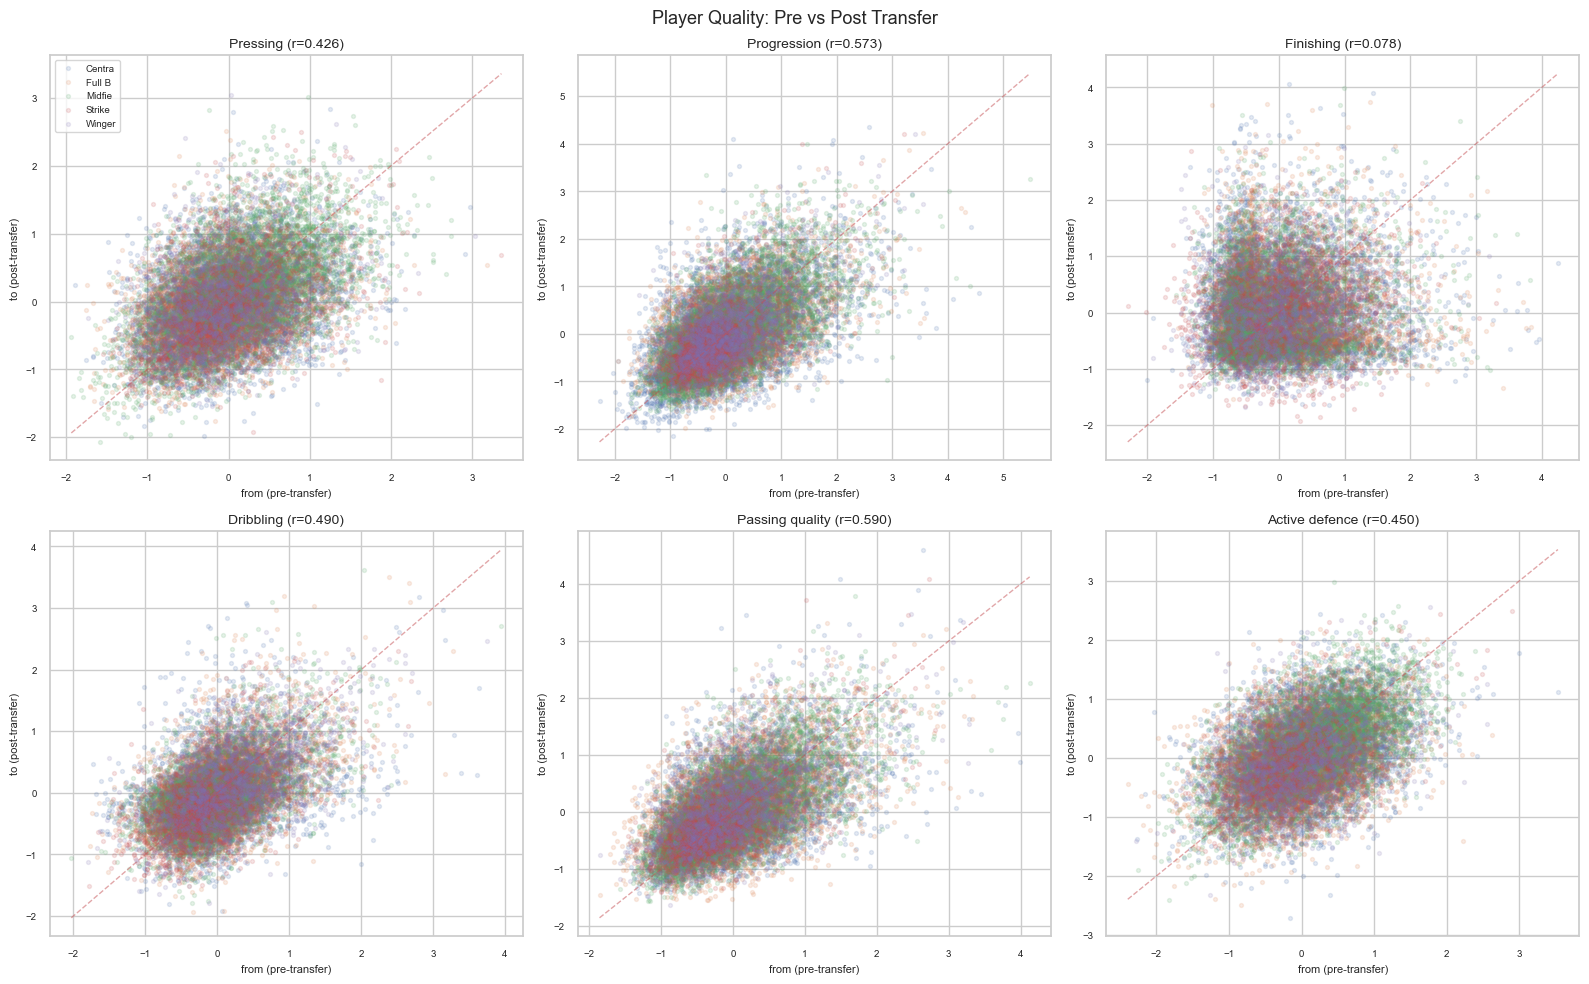

In [20]:
# 5d. from vs to scatter for a few key qualities
sample_qs = ["Pressing", "Progression", "Finishing", "Dribbling", "Passing quality", "Active defence"]
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, qname in enumerate(sample_qs):
    ax = axes[i]
    f_col = f"from_{qname}"
    t_col = f"to_{qname}"
    valid = df[[f_col, t_col, "from_position"]].dropna()
    for pos in pos_list:
        sub = valid[valid["from_position"] == pos]
        ax.scatter(sub[f_col], sub[t_col], alpha=0.15, s=8, label=pos[:6])
    ax.plot([valid[f_col].min(), valid[f_col].max()],
            [valid[f_col].min(), valid[f_col].max()], "r--", lw=1, alpha=0.5)
    r = valid[f_col].corr(valid[t_col])
    ax.set_title(f"{qname} (r={r:.3f})", fontsize=10)
    ax.set_xlabel("from (pre-transfer)", fontsize=8)
    ax.set_ylabel("to (post-transfer)", fontsize=8)
    ax.tick_params(labelsize=7)

axes[0].legend(fontsize=7, loc="upper left")
plt.suptitle("Player Quality: Pre vs Post Transfer", fontsize=13)
plt.tight_layout()
plt.show()

In [21]:
# 5e. from vs to correlation by POSITION
print("Player QS: from ↔ to correlation BY POSITION")
for pos in pos_list:
    sub = df[df["from_position"] == pos]
    print(f"\n{pos} (n={len(sub):,}):")
    for qname in TWELVE_QS_NAMES:
        f_col = f"from_{qname}"
        t_col = f"to_{qname}"
        valid = sub[[f_col, t_col]].dropna()
        if len(valid) > 10:
            r = valid[f_col].corr(valid[t_col])
            print(f"  {qname:<25s} r={r:+.3f} (n={len(valid):,})")

Player QS: from ↔ to correlation BY POSITION

Central Defender (n=4,766):
  Active defence            r=+0.380 (n=4,762)
  Aerial threat             r=+0.382 (n=4,756)
  Box threat                r=+0.382 (n=4,766)
  Chance prevention         r=+0.075 (n=4,766)
  Composure                 r=+0.310 (n=4,766)
  Defensive heading         r=+0.539 (n=4,766)
  Dribbling                 r=+0.320 (n=4,453)
  Effectiveness             r=+0.194 (n=4,625)
  Finishing                 r=+0.043 (n=4,625)
  Hold-up play              r=+0.246 (n=2,837)
  Intelligent defence       r=+0.340 (n=4,766)
  Involvement               r=+0.399 (n=4,766)
  Passing quality           r=+0.497 (n=4,766)
  Poaching                  r=+0.072 (n=919)
  Pressing                  r=+0.301 (n=4,766)
  Progression               r=+0.516 (n=4,766)
  Providing teammates       r=+0.216 (n=4,760)
  Run quality               r=+0.333 (n=4,741)
  Territorial dominance     r=+0.155 (n=4,766)
  Winning duels             r=+0.26

### DECISION NEEDED — Player QS modelling considerations

- Which qualities have **high from→to correlation** (player retains quality) vs **low** (quality changes a lot)?
- High-correlation qualities are easier to predict but maybe less interesting
- Low-correlation qualities might be where team context matters most
- Per-position models will naturally handle position-specific quality availability

---
## 6. Team qualities — distributions & analysis

In [22]:
# 6a. Team quality descriptive stats
print("from_team PROJECTED qualities:")
print(df[from_tq].describe().round(3).to_string())
print(f"\nto_team CURRENT qualities:")
print(df[to_tq].describe().round(3).to_string())

from_team PROJECTED qualities:
       from_q_proj_DEFENCE  from_q_proj_DEFENSIVE_TRANSITION  from_q_proj_ATTACKING_TRANSITION  from_q_proj_ATTACK  from_q_proj_PENETRATION  from_q_proj_CHANCE_CREATION  from_q_proj_OUTCOME
count            17184.000                         17184.000                         17184.000           17184.000                17184.000                    17184.000            17184.000
mean                 0.021                             0.029                             0.031              -0.103                   -0.073                       -0.013               -0.097
std                  0.947                             0.787                             0.549               0.670                    0.622                        0.576                0.977
min                 -6.872                           -15.692                            -4.071              -3.642                   -3.614                       -4.223               -5.362
25%                

In [23]:
# 6b. Team quality null analysis
print("Team quality nulls:")
print(f"  from projected: {df[from_tq[0]].isnull().sum():,} ({100*df[from_tq[0]].isnull().sum()/len(df):.1f}%)")
print(f"  to current:     {df[to_tq[0]].isnull().sum():,} ({100*df[to_tq[0]].isnull().sum()/len(df):.1f}%)")
print(f"  either null:    {(df[from_tq[0]].isnull() | df[to_tq[0]].isnull()).sum():,}")
print(f"  both null:      {(df[from_tq[0]].isnull() & df[to_tq[0]].isnull()).sum():,}")

# Which seasons/comps?
tq_null = df[from_tq[0]].isnull() | df[to_tq[0]].isnull()
print(f"\nNull team quality rows by from_season:")
print(df.loc[tq_null, "from_season"].value_counts().sort_index().to_string())
print(f"\nNull team quality rows by competition (top 10):")
print(df.loc[tq_null, "from_competition"].value_counts().head(10).to_string())

Team quality nulls:
  from projected: 881 (4.9%)
  to current:     610 (3.4%)
  either null:    1,081
  both null:      410

Null team quality rows by from_season:
from_season
2018    212
2019    424
2020    259
2021     33
2022     21
2023    122
2024     10

Null team quality rows by competition (top 10):
from_competition
516     95
796     72
535     63
725     46
286     38
534     37
287     37
520     35
551     32
1710    30


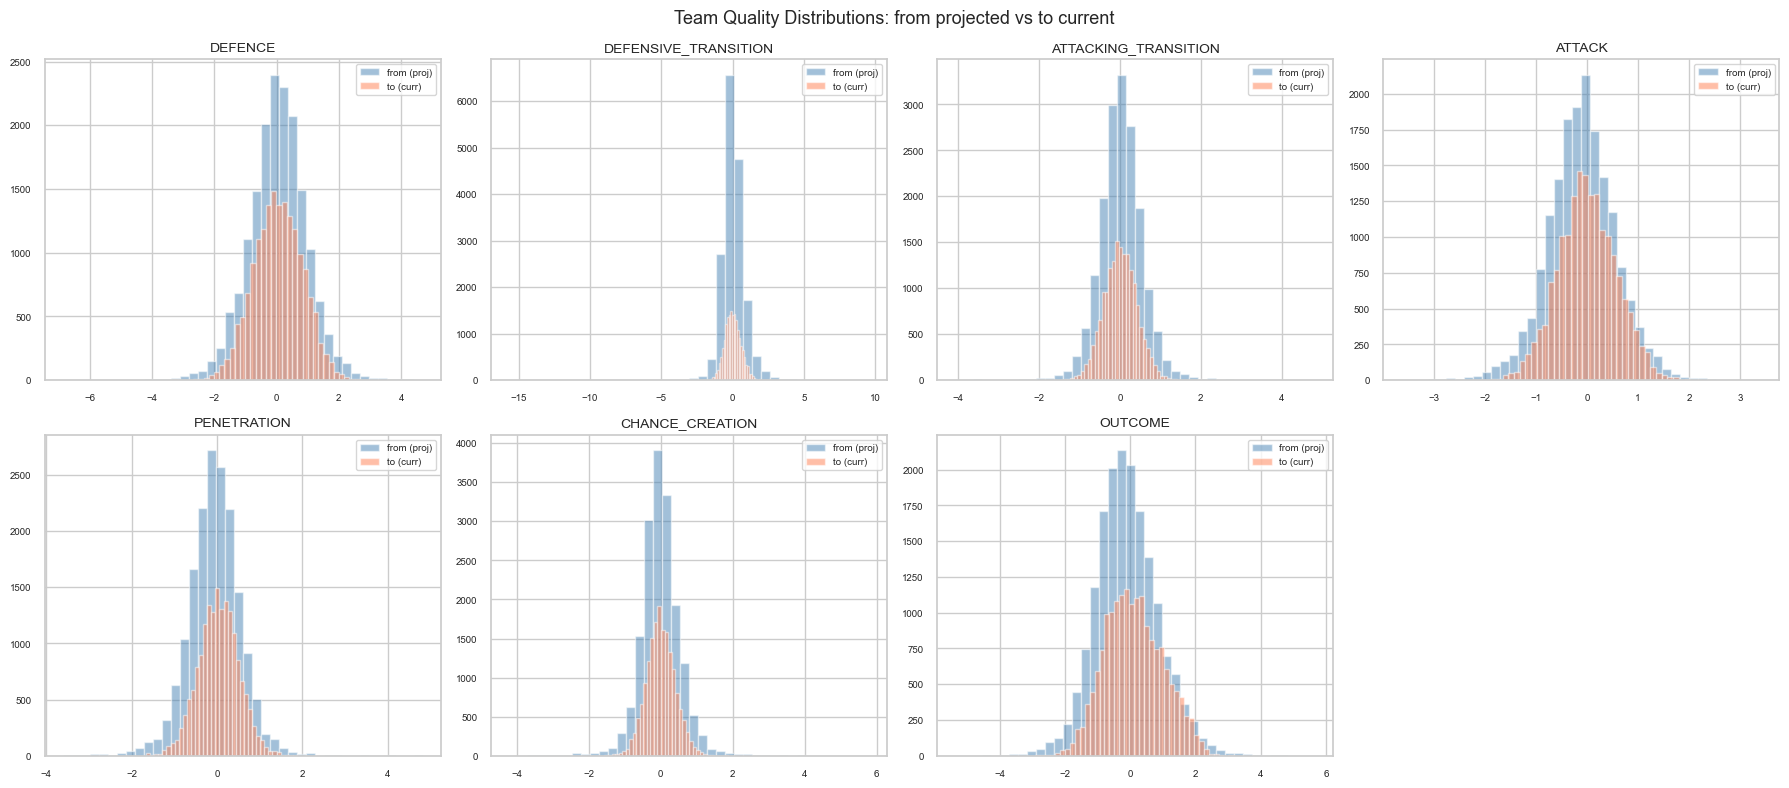

In [24]:
# 6c. Team quality distributions — from projected vs to current
QUALITY_NAMES = ["DEFENCE", "DEFENSIVE_TRANSITION", "ATTACKING_TRANSITION",
                 "ATTACK", "PENETRATION", "CHANCE_CREATION", "OUTCOME"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, q in enumerate(QUALITY_NAMES):
    ax = axes[i]
    f_col = f"from_q_proj_{q}"
    t_col = f"to_q_{q}"
    ax.hist(df[f_col].dropna(), bins=40, alpha=0.5, label="from (proj)", color="steelblue")
    ax.hist(df[t_col].dropna(), bins=40, alpha=0.5, label="to (curr)", color="coral")
    ax.set_title(q, fontsize=10)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

axes[7].set_visible(False)
plt.suptitle("Team Quality Distributions: from projected vs to current", fontsize=13)
plt.tight_layout()
plt.show()

In [25]:
# 6d. from projected vs to current: are players moving to better/worse teams?
print("Team quality shift: to_current - from_projected (positive = moving to 'higher' quality team)")
print(f"{'Quality':<30s} {'mean_diff':>10s} {'median_diff':>12s} {'% positive':>12s}")
print("-" * 70)
for q in QUALITY_NAMES:
    f_col = f"from_q_proj_{q}"
    t_col = f"to_q_{q}"
    diff = df[t_col] - df[f_col]
    valid = diff.dropna()
    print(f"{q:<30s} {valid.mean():>+10.4f} {valid.median():>+12.4f} {100*(valid > 0).mean():>11.1f}%")

Team quality shift: to_current - from_projected (positive = moving to 'higher' quality team)
Quality                         mean_diff  median_diff   % positive
----------------------------------------------------------------------
DEFENCE                           +0.0191      +0.0185        50.6%
DEFENSIVE_TRANSITION              -0.0402      -0.0113        49.5%
ATTACKING_TRANSITION              -0.0252      -0.0222        48.6%
ATTACK                            +0.1036      +0.0906        54.2%
PENETRATION                       +0.1030      +0.0968        55.8%
CHANCE_CREATION                   +0.0113      +0.0162        51.1%
OUTCOME                           +0.2084      +0.2294        57.7%


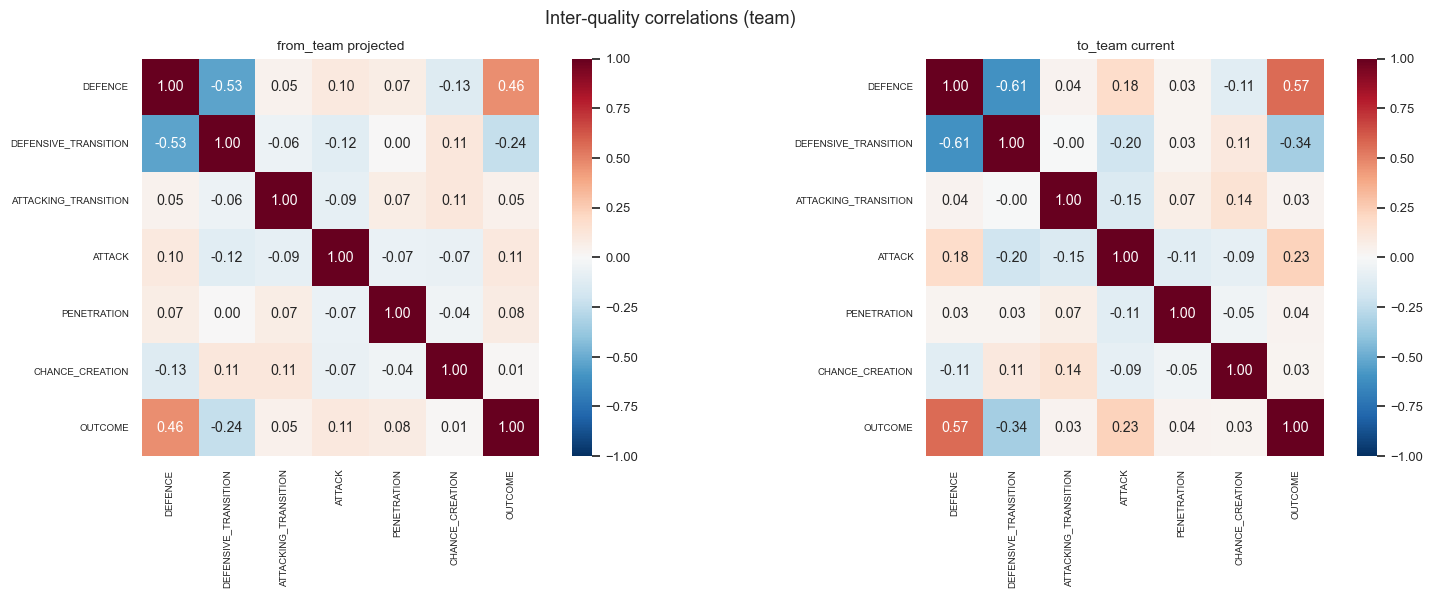

In [26]:
# 6e. Correlation between team qualities (from projected)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

corr_from = df[from_tq].corr()
sns.heatmap(corr_from, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            xticklabels=[c.replace("from_q_proj_", "") for c in from_tq],
            yticklabels=[c.replace("from_q_proj_", "") for c in from_tq],
            ax=axes[0], square=True)
axes[0].set_title("from_team projected", fontsize=10)
axes[0].tick_params(labelsize=7)

corr_to = df[to_tq].corr()
sns.heatmap(corr_to, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            xticklabels=[c.replace("to_q_", "") for c in to_tq],
            yticklabels=[c.replace("to_q_", "") for c in to_tq],
            ax=axes[1], square=True)
axes[1].set_title("to_team current", fontsize=10)
axes[1].tick_params(labelsize=7)

plt.suptitle("Inter-quality correlations (team)", fontsize=13)
plt.tight_layout()
plt.show()

### DECISION NEEDED — Team qualities

- Team quality nulls (~5% from, ~3.4% to): drop those rows? Impute? Leave as-is and let the model handle?
- Any team qualities highly correlated with each other? Consider dropping one of a pair?

---
## 7. Team z-scores — distributions & analysis

In [27]:
# 7a. Team z-score descriptive stats
print(f"from_team PROJECTED z-scores ({len(from_tz)} cols):")
print(df[from_tz].describe().T[["count", "mean", "std", "min", "max"]].round(3).to_string())
print(f"\nto_team CURRENT z-scores ({len(to_tz)} cols):")
print(df[to_tz].describe().T[["count", "mean", "std", "min", "max"]].round(3).to_string())

from_team PROJECTED z-scores (22 cols):
                                                                         count   mean   std     min    max
from_z_proj_box_entries_from_carries_pct                             17184.000 -0.260 1.233  -7.949  8.665
from_z_proj_box_entries_from_crosses_pct                             17184.000  0.106 1.143  -5.394  9.679
from_z_proj_buildups_from_goalkicks_pct                              17182.000 -0.169 1.118  -5.323  8.703
from_z_proj_crosses_per_final_third_possession                       17184.000 -0.055 1.138  -5.849  7.143
from_z_proj_defensive_action_height_m                                17184.000 -0.075 1.107  -7.475  7.429
from_z_proj_defensive_intensity                                      17184.000  0.205 1.288  -8.842  8.564
from_z_proj_final_third_entry_within_10s_after_recovery_own_half_pct 17184.000  0.088 1.211  -7.885  9.114
from_z_proj_final_third_recoveries_pct                               17184.000 -0.104 1.245  -7.744 11.4

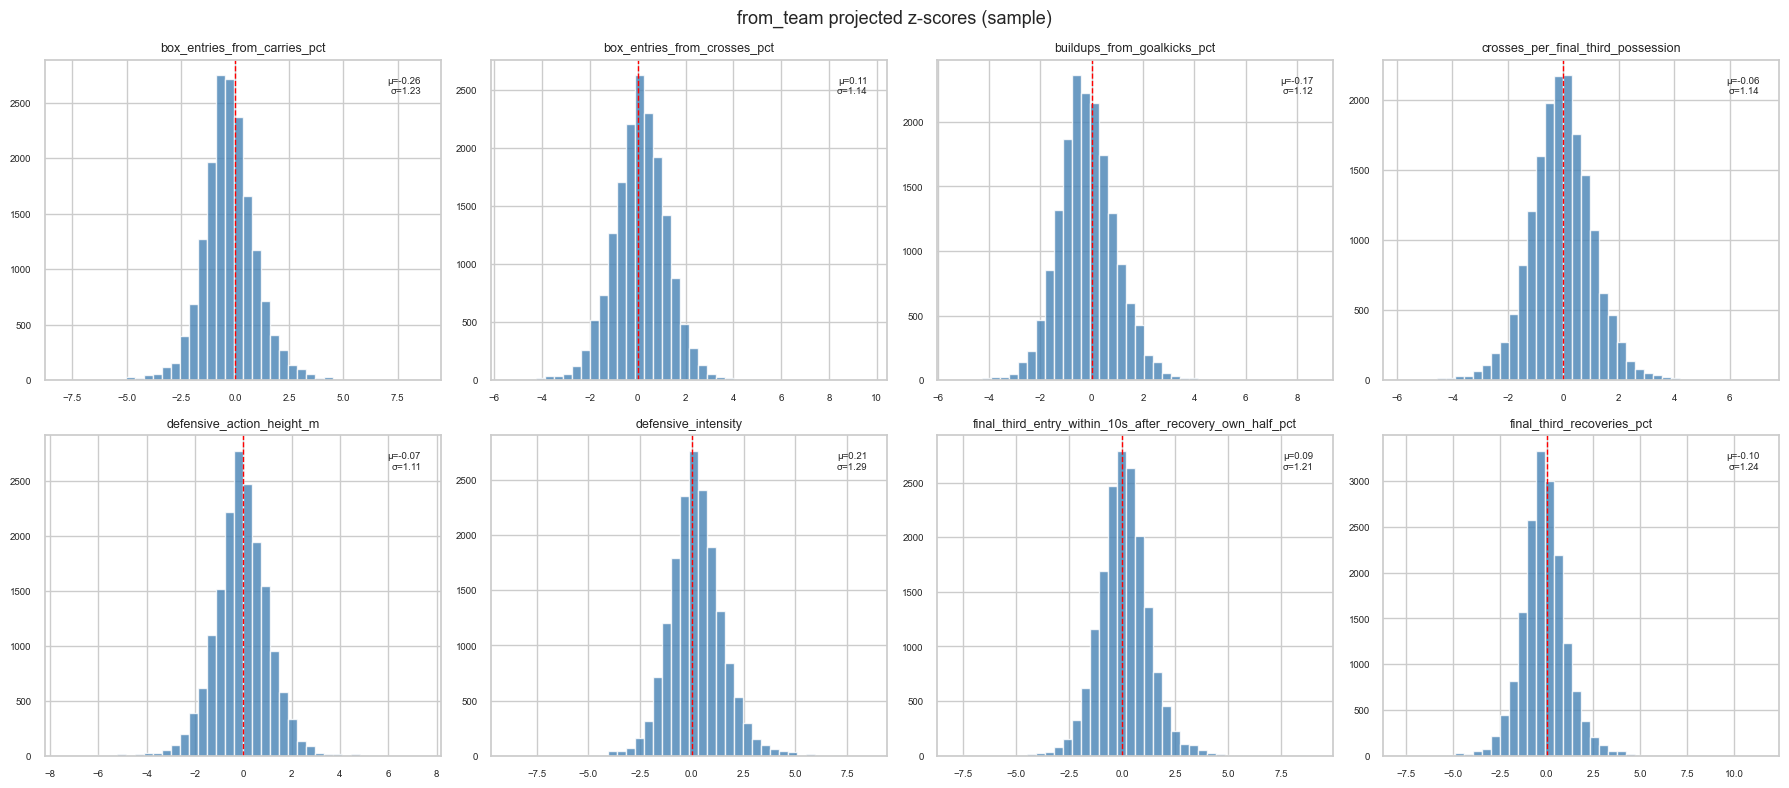

In [28]:
# 7b. z-score distributions — should be roughly normal
# Plot a sample of 8 z-scores
sample_z = from_tz[:8]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(sample_z):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=40, color="steelblue", edgecolor="white", alpha=0.8)
    ax.axvline(0, color="red", ls="--", lw=1)
    ax.set_title(col.replace("from_z_proj_", ""), fontsize=9)
    ax.text(0.95, 0.95, f"μ={data.mean():.2f}\nσ={data.std():.2f}",
            transform=ax.transAxes, fontsize=7, va="top", ha="right")
    ax.tick_params(labelsize=7)

plt.suptitle("from_team projected z-scores (sample)", fontsize=13)
plt.tight_layout()
plt.show()

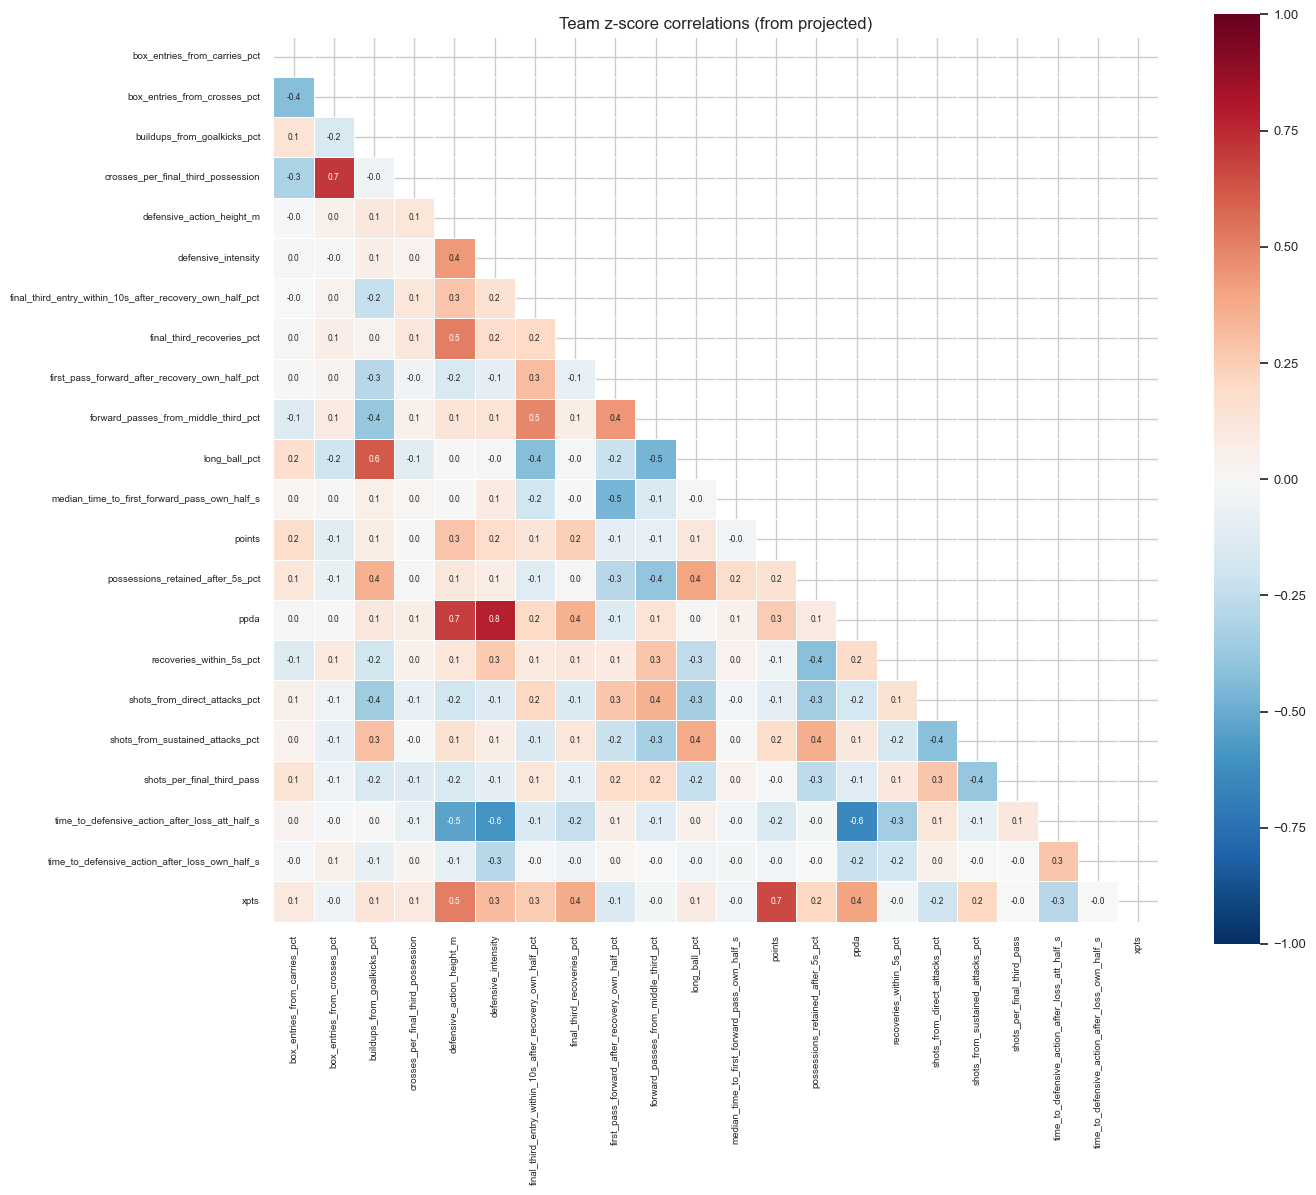

In [29]:
# 7c. Correlation between team z-scores (from proj) — are many redundant?
corr_tz = df[from_tz].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_tz, dtype=bool))
sns.heatmap(corr_tz, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            xticklabels=[c.replace("from_z_proj_", "") for c in from_tz],
            yticklabels=[c.replace("from_z_proj_", "") for c in from_tz],
            ax=ax, square=True, linewidths=0.5, annot=True, fmt=".1f", annot_kws={"size": 6})
ax.set_title("Team z-score correlations (from projected)", fontsize=12)
ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()

In [30]:
# 7d. Highly correlated z-score pairs
high_pairs = []
for i in range(len(corr_tz.columns)):
    for j in range(i+1, len(corr_tz.columns)):
        r = corr_tz.iloc[i, j]
        if abs(r) > 0.7:
            high_pairs.append({
                "z1": corr_tz.columns[i].replace("from_z_proj_", ""),
                "z2": corr_tz.columns[j].replace("from_z_proj_", ""),
                "r": round(r, 3),
            })

if high_pairs:
    df_hp = pd.DataFrame(high_pairs).sort_values("r", key=abs, ascending=False)
    print(f"Team z-score pairs with |r| > 0.7: {len(df_hp)}")
    print(df_hp.to_string(index=False))
else:
    print("No team z-score pairs with |r| > 0.7")

Team z-score pairs with |r| > 0.7: 2
                          z1                                 z2     r
         defensive_intensity                               ppda 0.778
box_entries_from_crosses_pct crosses_per_final_third_possession 0.706


### DECISION NEEDED — Team z-scores

- These 21 z-scores are the **building blocks** of the 7 team qualities
- If the model uses both qualities AND z-scores, there's inherent redundancy
- Options: (a) use only qualities, (b) use only z-scores, (c) use both and let the model regularise, (d) use qualities + only z-scores not fully captured by qualities
- Any highly correlated z-score pairs to be aware of?

---
## 8. Cross-group relationships

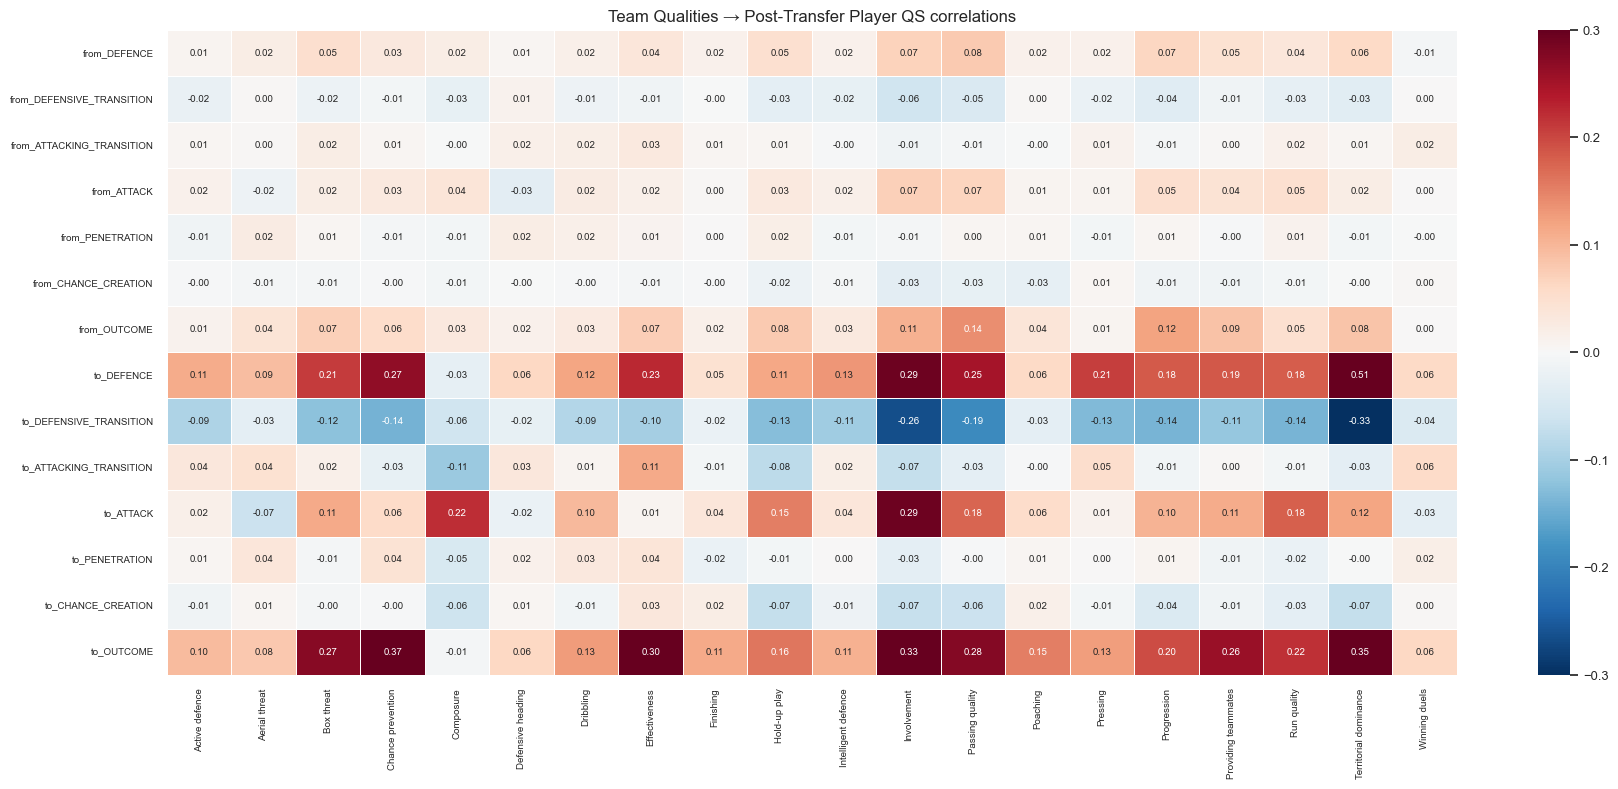

In [31]:
# 8a. Team qualities → Player QS (to): does team style predict post-transfer player quality?
cross = df[from_tq + to_tq + to_pqs].corr().loc[from_tq + to_tq, to_pqs]

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(cross.values, cmap="RdBu_r", center=0, vmin=-0.3, vmax=0.3,
            xticklabels=[c.replace("to_", "") for c in to_pqs],
            yticklabels=[c.replace("from_q_proj_", "from_").replace("to_q_", "to_") for c in from_tq + to_tq],
            ax=ax, linewidths=0.5, annot=True, fmt=".2f", annot_kws={"size": 7})
ax.set_title("Team Qualities → Post-Transfer Player QS correlations", fontsize=12)
ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()

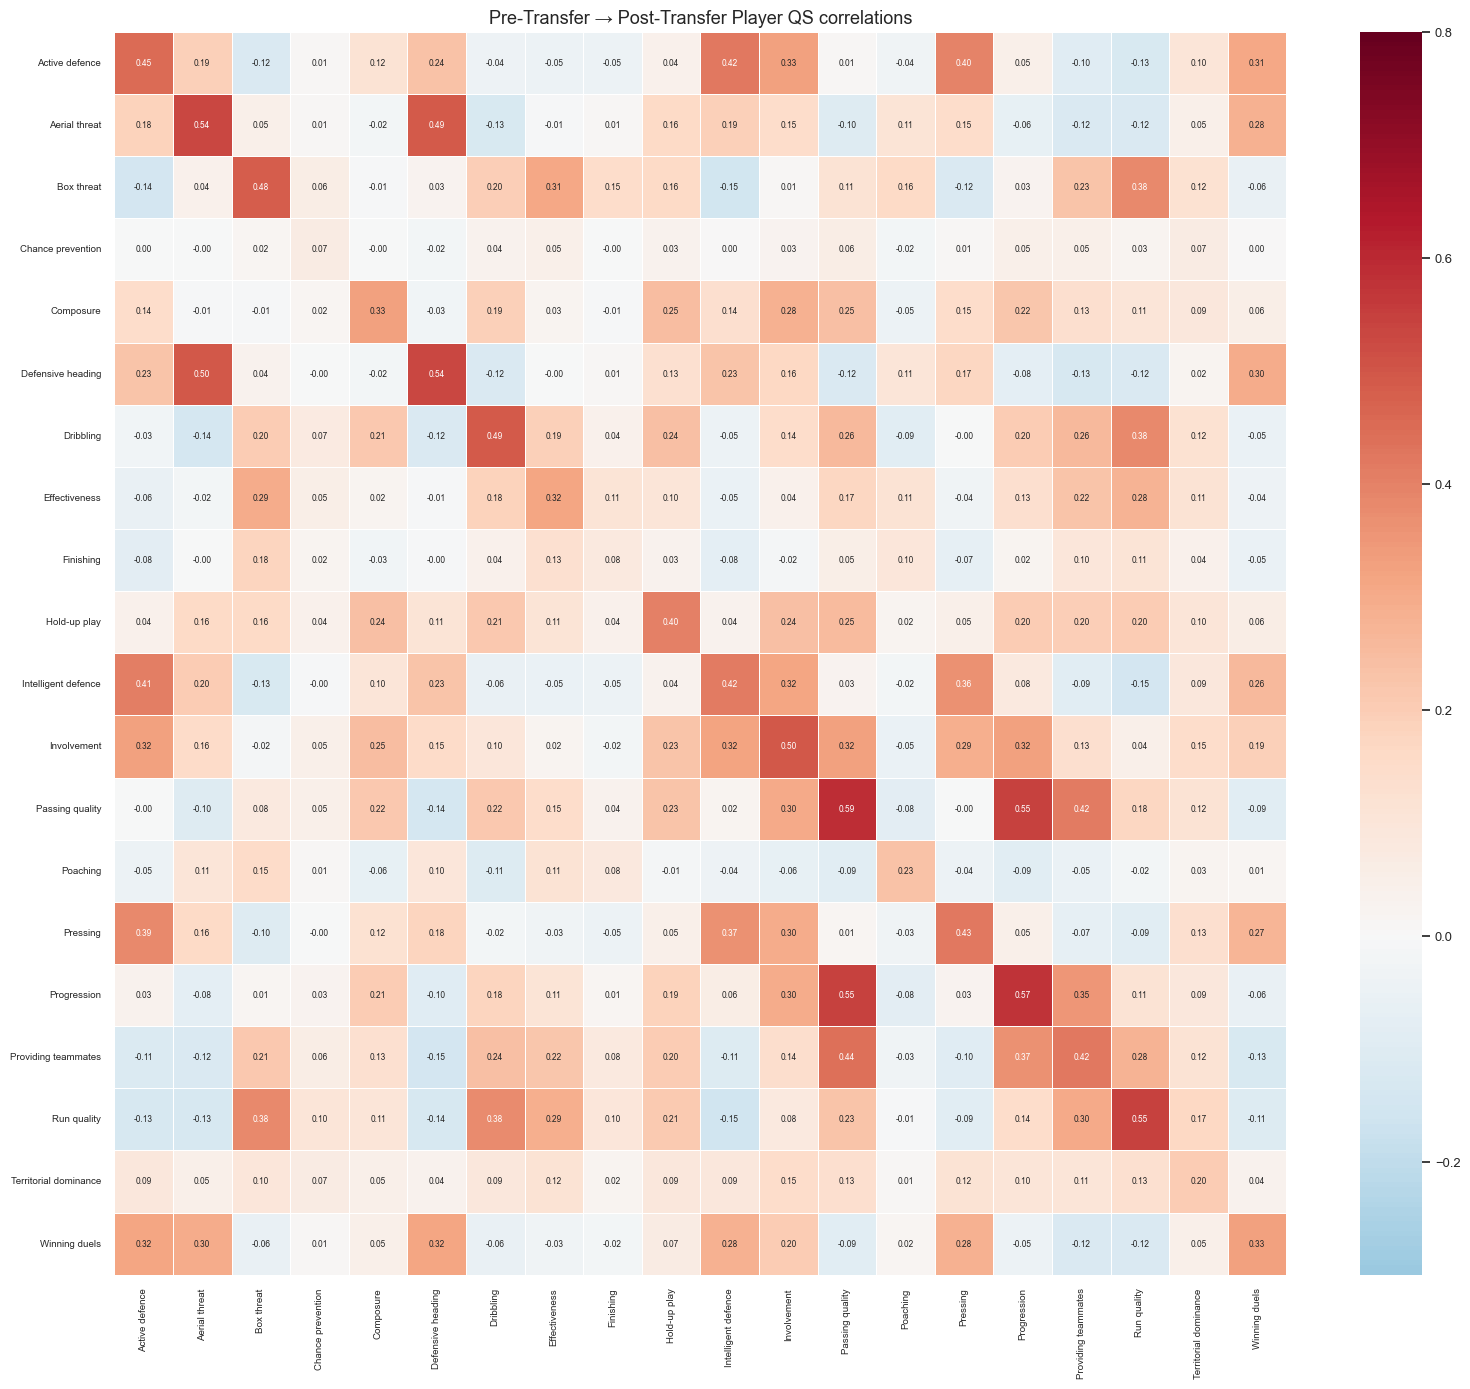

In [32]:
# 8b. Pre-transfer player QS → Post-transfer player QS: the core prediction relationship
# Correlation matrix: from_player_qs vs to_player_qs
cross_pqs = df[from_pqs + to_pqs].corr().loc[from_pqs, to_pqs]

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(cross_pqs.values, cmap="RdBu_r", center=0, vmin=-0.3, vmax=0.8,
            xticklabels=[c.replace("to_", "") for c in to_pqs],
            yticklabels=[c.replace("from_", "") for c in from_pqs],
            ax=ax, linewidths=0.5, annot=True, fmt=".2f", annot_kws={"size": 6})
ax.set_title("Pre-Transfer → Post-Transfer Player QS correlations", fontsize=13)
ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()

In [33]:
# 8c. Diagonal correlations: same quality pre vs post
print("Same-quality diagonal: from_Q → to_Q")
print(f"{'Quality':<25s} {'r (all)':>8s} {'r (CD)':>8s} {'r (FB)':>8s} {'r (MF)':>8s} {'r (ST)':>8s} {'r (WI)':>8s}")
print("-" * 85)
pos_short = {"Central Defender": "CD", "Full Back": "FB", "Midfielder": "MF", "Striker": "ST", "Winger": "WI"}
for qname in TWELVE_QS_NAMES:
    f_col = f"from_{qname}"
    t_col = f"to_{qname}"
    valid_all = df[[f_col, t_col]].dropna()
    r_all = valid_all[f_col].corr(valid_all[t_col])
    r_pos = {}
    for pos in pos_list:
        sub = df.loc[df["from_position"] == pos, [f_col, t_col]].dropna()
        r_pos[pos_short[pos]] = sub[f_col].corr(sub[t_col]) if len(sub) > 10 else np.nan
    vals = [f"{r_pos.get(s, np.nan):>8.3f}" if not np.isnan(r_pos.get(s, np.nan)) else f"{'N/A':>8s}" for s in ["CD", "FB", "MF", "ST", "WI"]]
    print(f"{qname:<25s} {r_all:>8.3f} {' '.join(vals)}")

Same-quality diagonal: from_Q → to_Q
Quality                    r (all)   r (CD)   r (FB)   r (MF)   r (ST)   r (WI)
-------------------------------------------------------------------------------------
Active defence               0.450    0.380    0.364    0.575    0.413    0.383
Aerial threat                0.535    0.382    0.398    0.536    0.766    0.576
Box threat                   0.485    0.382    0.437    0.641    0.335    0.438
Chance prevention            0.069    0.075    0.062      N/A      N/A      N/A
Composure                    0.327    0.310    0.328    0.315    0.334    0.357
Defensive heading            0.537    0.539    0.477    0.606    0.512    0.426
Dribbling                    0.490    0.320    0.507    0.541    0.528    0.566
Effectiveness                0.315    0.194    0.305    0.446    0.276    0.289
Finishing                    0.078    0.043    0.046    0.138    0.082    0.063
Hold-up play                 0.402    0.246    0.324    0.457    0.565    0.4

In [34]:
# 8d. Age and minutes vs player quality change
print("Age & Minutes correlations with quality CHANGE (to - from):")
print(f"{'Quality':<25s} {'r(age)':>8s} {'r(from_min)':>12s} {'r(to_min)':>10s}")
print("-" * 60)
for qname in TWELVE_QS_NAMES:
    f_col = f"from_{qname}"
    t_col = f"to_{qname}"
    change = df[t_col] - df[f_col]
    r_age = change.corr(df["player_season_age"])
    r_from_min = change.corr(df["from_Minutes"])
    r_to_min = change.corr(df["to_Minutes"])
    print(f"{qname:<25s} {r_age:>+8.3f} {r_from_min:>+12.3f} {r_to_min:>+10.3f}")

Age & Minutes correlations with quality CHANGE (to - from):
Quality                     r(age)  r(from_min)  r(to_min)
------------------------------------------------------------
Active defence              -0.025       -0.033     +0.011
Aerial threat               -0.047       -0.007     -0.005
Box threat                  -0.096       -0.003     +0.031
Chance prevention           -0.088       +0.251     -0.203
Composure                   -0.011       -0.021     +0.008
Defensive heading           -0.044       -0.013     -0.007
Dribbling                   -0.043       -0.016     +0.015
Effectiveness               -0.059       +0.021     -0.006
Finishing                   -0.034       -0.041     +0.042
Hold-up play                -0.084       +0.005     +0.012
Intelligent defence         -0.043       -0.021     +0.009
Involvement                 -0.126       +0.014     +0.014
Passing quality             -0.124       -0.024     +0.025
Poaching                    -0.013       +0.001     +

### DECISION NEEDED — Cross-group relationships

- The from→to diagonal shows how much each quality persists after transfer. **High r** = stable quality, **low r** = quality that changes a lot (potentially more influenced by team context)
- Team qualities show low-to-moderate correlations with post-transfer player QS — there IS signal from team style
- Age and minutes: do they correlate with quality change? If so, include as features

---
## 9. Rows that would be lost to nulls

In [35]:
# 9a. If we drop ALL rows with any null in player QS (excluding the 4 problematic ones)
safe_qs = [q for q in TWELVE_QS_NAMES if q not in ["Chance prevention", "Poaching", "Territorial dominance", "Hold-up play"]]
safe_from = [f"from_{q}" for q in safe_qs]
safe_to = [f"to_{q}" for q in safe_qs]

null_safe_pqs = df[safe_from + safe_to].isnull().any(axis=1)
null_tq = df[from_tq + to_tq].isnull().any(axis=1)
null_tz = df[from_tz + to_tz].isnull().any(axis=1)

print("Rows lost under different null strategies:")
print(f"  Any null in 16 'safe' player QS (from+to):  {null_safe_pqs.sum():,} ({100*null_safe_pqs.sum()/len(df):.1f}%)")
print(f"  Any null in team qualities:                  {null_tq.sum():,} ({100*null_tq.sum()/len(df):.1f}%)")
print(f"  Any null in team z-scores:                   {null_tz.sum():,} ({100*null_tz.sum()/len(df):.1f}%)")
print(f"  Any of the above:                            {(null_safe_pqs | null_tq | null_tz).sum():,} ({100*(null_safe_pqs | null_tq | null_tz).sum()/len(df):.1f}%)")
print(f"\n  Remaining rows:                              {len(df) - (null_safe_pqs | null_tq | null_tz).sum():,}")

Rows lost under different null strategies:
  Any null in 16 'safe' player QS (from+to):  982 (5.4%)
  Any null in team qualities:                  1,081 (6.0%)
  Any null in team z-scores:                   1,091 (6.0%)
  Any of the above:                            2,005 (11.1%)

  Remaining rows:                              16,060


In [ ]:
# 9b. If we also include the 4 problematic QS, how many MORE rows lost?
all_pqs_null = df[from_pqs + to_pqs].isnull().any(axis=1)
print(f"Rows with ANY null in ALL 20 player QS (from+to): {all_pqs_null.sum():,} ({100*all_pqs_null.sum()/len(df):.1f}%)")
print(f"  → This is dominated by Chance prevention, Poaching, Territorial dominance")
print(f"  → These are null BY DESIGN for certain positions, not data quality issues")

In [ ]:
# 9c. What if we go position-specific? Per position, how complete is the data?
print("Per-position completeness (16 safe QS + team Q):")
print(f"{'Position':<20s} {'n_total':>8s} {'n_complete':>10s} {'%_complete':>10s}")
print("-" * 55)

check_cols = safe_from + safe_to + from_tq + to_tq
for pos in pos_list:
    sub = df[df["from_position"] == pos]
    complete = sub[check_cols].notna().all(axis=1).sum()
    print(f"{pos:<20s} {len(sub):>8,} {complete:>10,} {100*complete/len(sub):>9.1f}%")

# And with ALL 20 QS per position (some will be very low)
print(f"\nPer-position completeness (ALL 20 QS + team Q):")
print(f"{'Position':<20s} {'n_total':>8s} {'n_complete':>10s} {'%_complete':>10s}")
print("-" * 55)

check_all = from_pqs + to_pqs + from_tq + to_tq
for pos in pos_list:
    sub = df[df["from_position"] == pos]
    complete = sub[check_all].notna().all(axis=1).sum()
    print(f"{pos:<20s} {len(sub):>8,} {complete:>10,} {100*complete/len(sub):>9.1f}%")

### DECISION NEEDED — Null handling strategy

Key trade-off:
- Using all 20 QS per position → lose many rows for certain positions (QS null by design)
- Using 16 "safe" QS → keep ~95%+ rows but lose Chance prevention, Poaching, Territorial dominance, Hold-up play
- Position-specific models that only use available QS per position → best of both worlds?
- Team quality nulls (~5%): likely drop those rows or impute

---
## 10. Overall data quality score

In [36]:
# 10a. Summary dashboard
print("=" * 70)
print("v5 FINAL REVIEW SUMMARY")
print("=" * 70)
print(f"\nDataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Positions: {', '.join(pos_list)}")
print(f"Seasons: {sorted(df['from_season'].unique())}")
print(f"Competitions: {df['from_competition'].nunique()}")
print(f"Unique players: {df['wy_player_id'].nunique():,}")

print(f"\n--- FEATURE SUMMARY ---")
print(f"Player qualities (from+to):     20+20 = 40  (4 with high positional nulls)")
print(f"Team qualities (from+to):        7+7  = 14  (~5% null)")
print(f"Team z-scores (from+to):        21+21 = 42  (~5% null)")
print(f"Player demographics:             age (0% null), height/weight (77% null)")
print(f"Financials:                      value (11% null), fee (36% null)")
print(f"Playing time:                    from/to Minutes (0% null)")

print(f"\n--- DECISIONS PENDING ---")
print(f"1. Height & weight (77% null): drop or impute?")
print(f"2. Transfer value/fee nulls: drop, impute, or exclude as features?")
print(f"3. 4 player QS with position-specific nulls: per-position models or drop?")
print(f"4. Team quality/z-score nulls (~5%): drop rows?")
print(f"5. Comp metadata nulls (30%): drop these columns?")
print(f"6. Team z-scores: use alongside qualities or only qualities?")
print(f"7. Competitions with very few transfers: threshold?")
print(f"8. Player ID: drop before modelling (keep for interpretation)?")

v5 FINAL REVIEW SUMMARY

Dataset: 18,065 rows x 120 columns
Positions: Central Defender, Full Back, Midfielder, Striker, Winger
Seasons: [np.int16(2018), np.int16(2019), np.int16(2020), np.int16(2021), np.int16(2022), np.int16(2023), np.int16(2024)]
Competitions: 240
Unique players: 14,487

--- FEATURE SUMMARY ---
Player qualities (from+to):     20+20 = 40  (4 with high positional nulls)
Team qualities (from+to):        7+7  = 14  (~5% null)
Team z-scores (from+to):        21+21 = 42  (~5% null)
Player demographics:             age (0% null), height/weight (77% null)
Financials:                      value (11% null), fee (36% null)
Playing time:                    from/to Minutes (0% null)

--- DECISIONS PENDING ---
1. Height & weight (77% null): drop or impute?
2. Transfer value/fee nulls: drop, impute, or exclude as features?
3. 4 player QS with position-specific nulls: per-position models or drop?
4. Team quality/z-score nulls (~5%): drop rows?
5. Comp metadata nulls (30%): drop the